In [1]:
import numpy as np

def patchify(x, P):
    """x: (1, H, W, C) -> (N, P*P*C)"""
    H, W, C = x.shape[1], x.shape[2], x.shape[3]
    n_h, n_w = H // P, W // P
    return x.reshape(n_h, P, n_w, P, C).transpose(0, 2, 1, 3, 4).reshape(n_h * n_w, P * P * C)

rng = np.random.default_rng(0)
H = W = 224
C = 3
x = rng.standard_normal((1, H, W, C))
base_cost = (196 + 1) ** 2   # attn matrix elements at P=16

print(f"{'P':>3} {'N':>5} {'patch_dim':>10} {'P*P*C':>7} {'N*P*P':>7}")
for P in [28, 16, 14, 8, 4]:
    p = patchify(x, P)
    N, dim = p.shape
    cost = (N + 1) ** 2
    print(f"{P:>3} {N:>5} {dim:>10} {P*P*C:>7} {N*P*P:>7}  attn_rel_vs_P16={cost/base_cost:.2f}")

Ps = np.array([4, 7, 8, 14, 16, 28])
Ns = (224 // Ps) ** 2
fit = Ns[0] * (Ps[0] / Ps) ** 2
print("measured N    :", Ns.tolist())
print("P^-2 prediction:", fit.astype(int).tolist())

  P     N  patch_dim   P*P*C   N*P*P
 28    64       2352    2352   50176  attn_rel_vs_P16=0.11
 16   196        768     768   50176  attn_rel_vs_P16=1.00
 14   256        588     588   50176  attn_rel_vs_P16=1.70
  8   784        192     192   50176  attn_rel_vs_P16=15.88
  4  3136         48      48   50176  attn_rel_vs_P16=253.57
measured N    : [3136, 1024, 784, 256, 196, 64]
P^-2 prediction: [3136, 1023, 784, 255, 196, 63]


In [ ]:
# # pip install transformers torch pillow
# import torch
# from PIL import Image
# from transformers import CLIPModel, CLIPProcessor

# model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
# proc = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")

# image = Image.open("fig.png")
# labels = ["a scatter plot", "a bar chart", "a Kaplan-Meier curve", "a heatmap"]

# inputs = proc(text=labels, images=image, return_tensors="pt", padding=True)
# with torch.no_grad():
#     logits = model(**inputs).logits_per_image          # 1 x K 相似度
#     probs = logits.softmax(dim=-1)                     # 注意：仅排序可信，非校准概率

# for lab, p in zip(labels, probs[0].tolist()):
#     print(f"{lab}: {p:.3f}")

In [5]:
import numpy as np
from scipy.optimize import minimize

def unit(v):
    return v / np.linalg.norm(v)

d, M = 64, 100
r0 = np.random.default_rng(5)
theta_star = unit(r0.standard_normal(d))   # scale not identifiable, direction only

def make_data(N, seed):
    r = np.random.default_rng(seed)
    Z = r.standard_normal((M, N, d))       # 1 true-pair candidate + N-1 controls per case
    eta = Z @ theta_star
    eta = eta - eta.max(axis=1, keepdims=True)
    p = np.exp(eta); p /= p.sum(axis=1, keepdims=True)   # noisy label generation
    y = np.array([r.choice(N, p=p[i]) for i in range(M)])
    return Z, y

def infonce_nll(theta, Z, y):
    s = Z @ theta                          # eta_ij = theta^T z_ij
    s = s - s.max(axis=1, keepdims=True)
    # -log softmax: both the InfoNCE loss and the conditional log-likelihood
    # of a 1:N matched design
    return -(s[np.arange(M), y] - np.log(np.exp(s).sum(axis=1))).mean()

def infonce_grad(theta, Z, y):
    s = Z @ theta
    p = np.exp(s - s.max(axis=1, keepdims=True))
    p /= p.sum(axis=1, keepdims=True)
    p[np.arange(M), y] -= 1.0
    return (p[:, :, None] * Z).sum(axis=1).mean(axis=0)

base = [round(infonce_nll(np.zeros(d), *make_data(N, 1)), 4) for N in [4, 16, 64]]
print("loss at theta=0 (chance level log N):", base)

print(f"\n{'N':>4} {'cos(theta_hat, theta*)':>24} {'sd over 5 reps':>16}")
for N in [4, 16, 64]:
    cos = []
    for rep in range(5):
        Z, y = make_data(N, seed=1000 * N + rep)
        res = minimize(infonce_nll, np.zeros(d), args=(Z, y), jac=infonce_grad, method="BFGS")
        cos.append(float(unit(res.x) @ theta_star))
    print(f"{N:>4} {np.mean(cos):>24.4f} {np.std(cos):>16.4f}")

loss at theta=0 (chance level log N): [1.3863, 2.7726, 4.1589]

   N   cos(theta_hat, theta*)   sd over 5 reps
   4                   0.6170           0.0574
  16                   0.7431           0.0363
  64                   0.7596           0.0158


step     0  loss = 1.0062
step  1000  loss = 0.3422
step  2000  loss = 0.3755
step  3000  loss = 0.3826
step  4000  loss = 0.3614
step  5000  loss = 0.3659
step  6000  loss = 0.3843
step  7000  loss = 0.3443
step  8000  loss = 0.3725
step  9000  loss = 0.3737
step 10000  loss = 0.3871
step 11000  loss = 0.3481
step 12000  loss = 0.3494
step 13000  loss = 0.3523
step 14000  loss = 0.3795
step 15000  loss = 0.3922
step 16000  loss = 0.3559
step 17000  loss = 0.3320
step 18000  loss = 0.3537
step 19000  loss = 0.2938
step 20000  loss = 0.2876
step 21000  loss = 0.3290
step 22000  loss = 0.3523
step 23000  loss = 0.3469
step 24000  loss = 0.3332
step 25000  loss = 0.3403
step 26000  loss = 0.3492
step 27000  loss = 0.3165
step 28000  loss = 0.3259
step 29000  loss = 0.3789
step 30000  loss = 0.2991


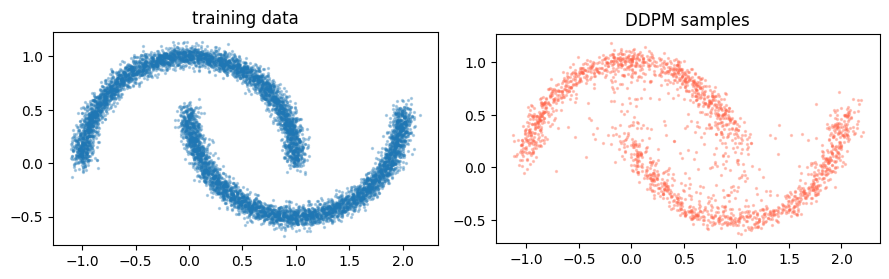

In [3]:
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# ================= 1. 定义一个简单的时间条件化 MLP =================
class TimeEmbedding(nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.dim = dim
    def forward(self, t):                       # t: (B,) 整数
        half = self.dim // 2
        freqs = torch.exp(-torch.arange(half, device=t.device) * 0.7)
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # (B, dim)

class Denoiser(nn.Module):
    def __init__(self, data_dim=2, hidden=128, t_dim=64):
        super().__init__()
        self.t_emb = TimeEmbedding(t_dim)
        self.net = nn.Sequential(
            nn.Linear(data_dim + t_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, data_dim),
        )
    def forward(self, x, t):
        h = torch.cat([x, self.t_emb(t)], dim=-1)
        return self.net(h)

# ================= 2. 造一个 2D "月亮" 分布作为训练数据 =================
from sklearn.datasets import make_moons
data, _ = make_moons(n_samples=8000, noise=0.05, random_state=0)
data = torch.tensor(data, dtype=torch.float32).to(device)   # (8000, 2)

# ================= 3. DDPM 训练 =================
T = 300                          # 玩具问题用小一点的步数
betas = torch.linspace(1e-4, 0.02, T).to(device)   # 线性噪声调度
alphas = 1.0 - betas
alphas_bar = torch.cumprod(alphas, dim=0)

model = Denoiser().to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-4)

N = data.shape[0]
for step in range(30001):
    idx = torch.randint(0, N, (256,), device=device)
    x0 = data[idx]                                     # 干净样本 (256, 2)
    t = torch.randint(0, T, (256,), device=device)      # 随机时间步
    noise = torch.randn_like(x0)
    # 前向加噪: x_t = sqrt(ab_t) x0 + sqrt(1-ab_t) eps
    ab = alphas_bar[t][:, None]
    x_t = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
    # 训练目标：预测加入的噪声
    loss = torch.nn.functional.mse_loss(model(x_t, t), noise)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 1000 == 0:
        print(f"step {step:5d}  loss = {loss.item():.4f}")

# ================= 4. 你原来的采样函数（原样保留） =================
@torch.no_grad()
def ddpm_sample(model, shape, T=1000, betas=None, device="cuda"):
    alphas = 1.0 - betas
    alphas_bar = torch.cumprod(alphas, dim=0)
    x = torch.randn(shape, device=device)
    for t in reversed(range(T)):
        z = torch.randn(shape, device=device) if t > 0 else torch.zeros(shape, device=device)
        a, ab = alphas[t], alphas_bar[t]
        eps = model(x, torch.full((shape[0],), t, device=device))
        x = (x - (1 - a) / torch.sqrt(1 - ab) * eps) / torch.sqrt(a) + torch.sqrt(betas[t]) * z
    return x

# ================= 5. 采样并可视化 =================
samples = ddpm_sample(model, shape=(2000, 2), T=T, betas=betas, device=device)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(data[:, 0].cpu(), data[:, 1].cpu(), s=2, alpha=0.3)
axes[0].set_title("training data")
axes[1].scatter(samples[:, 0].cpu(), samples[:, 1].cpu(), s=2, alpha=0.3, c="tomato")
axes[1].set_title("DDPM samples")
for ax in axes: ax.set_aspect("equal")
plt.tight_layout(); plt.savefig("ddpm_sample.png")



In [4]:
import numpy as np
from scipy import stats

rng = np.random.default_rng(0)
T = 1000
betas = np.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
abar = np.cumprod(alphas)
print(f"abar_1={abar[0]:.6f}  abar_500={abar[499]:.6f}  abar_T={abar[-1]:.2e}")

n = 20000
# symmetric two-component Gaussian mixture (zero skew, negative excess kurtosis)
x0 = np.where(rng.random(n) < 0.5,
              rng.normal(-2.0, 0.2, n),
              rng.normal(2.0, 0.2, n))
print(f"x0: Var={x0.var():.3f} Skew={stats.skew(x0):.3f} ExKurt={stats.kurtosis(x0):.3f} "
      f"P(|x|<0.5)={np.mean(np.abs(x0)<0.5):.4f}")

print(f"\n{'t':>5} {'abar_t':>10} {'Var':>8} {'Skew':>8} {'ExKurt':>8} {'P(|x|<0.5)':>11}")
for t in [0, 100, 300, 500, 700, 900, 999]:
    xt = np.sqrt(abar[t]) * x0 + np.sqrt(1.0 - abar[t]) * rng.standard_normal(n)
    print(f"{t+1:>5} {abar[t]:>10.5f} {xt.var():>8.3f} {stats.skew(xt):>8.3f} "
          f"{stats.kurtosis(xt):>8.3f} {np.mean(np.abs(xt)<0.5):>11.4f}")

print(f"\nN(0,1) reference P(|x|<0.5) = {2*stats.norm.cdf(0.5)-1:.4f}")
xt = np.sqrt(abar[-1]) * x0 + np.sqrt(1.0 - abar[-1]) * rng.standard_normal(n)
ks = stats.kstest(xt, "norm")
print(f"KS statistic vs N(0,1) at t=T: {ks.statistic:.4f} (n={n}, p={ks.pvalue:.3g})")

abar_1=0.999900  abar_500=0.078587  abar_T=4.04e-05
x0: Var=4.038 Skew=-0.013 ExKurt=-1.960 P(|x|<0.5)=0.0000

    t     abar_t      Var     Skew   ExKurt  P(|x|<0.5)
    1    0.99990    4.037   -0.013   -1.960      0.0000
  101    0.89514    3.709   -0.013   -1.849      0.0001
  301    0.39401    2.221   -0.005   -1.023      0.1574
  501    0.07780    1.222   -0.021   -0.104      0.3392
  701    0.00687    1.039   -0.014   -0.016      0.3805
  901    0.00027    1.007   -0.002    0.016      0.3830
 1000    0.00004    0.987    0.001   -0.032      0.3811

N(0,1) reference P(|x|<0.5) = 0.3829
KS statistic vs N(0,1) at t=T: 0.0046 (n=20000, p=0.779)


In [1]:
# import torch
# from PIL import Image
# from transformers import AutoProcessor, LlavaForConditionalGeneration

# ckpt = "llava-hf/llava-1.5-7b-hf"
# processor = AutoProcessor.from_pretrained(ckpt)
# model = LlavaForConditionalGeneration.from_pretrained(ckpt, torch_dtype=torch.float16, device_map="auto")

# prompt = "USER: <image>\nDescribe this statistical figure. List axis labels and any numbers you can see.\nASSISTANT:"
# image = Image.open("fig.png")
# inputs = processor(prompt, images=image, return_tensors="pt").to(model.device)
# out = model.generate(**inputs, max_new_tokens=256, do_sample=False)
# print(processor.decode(out[0], skip_special_tokens=True))

In [2]:
import numpy as np

rng = np.random.default_rng(7)
E, D, F = 240, 64, 4          # entities, embedding dim, family size (confusable)
n_fam = E // F

def unit(v):
    return v / np.linalg.norm(v)

centers = np.array([unit(rng.standard_normal(D)) for _ in range(n_fam)])
ent_emb = np.zeros((E, D))
for f in range(n_fam):
    for m in range(F):
        u = unit(rng.standard_normal(D))
        ent_emb[f * F + m] = unit(0.9 * centers[f] + np.sqrt(1 - 0.9 ** 2) * u)

values = rng.integers(1, 51, E).astype(float)   # ground-truth fact value per entity

S_C, S_Q = 0.1, 0.1            # chunk encoding noise / query encoding noise
chunk_emb = np.array([unit(ent_emb[e] + S_C * rng.standard_normal(D)) for e in range(E)])

def closed_book(e):
    """parametric memory: recalls the value with Gaussian noise"""
    return values[e] + rng.normal(0, 10)

n_q = 4000
err_cb = err_rag = hits = 0
for _ in range(n_q):
    e = int(rng.integers(E))
    q = unit(ent_emb[e] + S_Q * rng.standard_normal(D))
    # closed-book answer
    err_cb += abs(closed_book(e) - values[e]) > 5
    # retrieval: top-1 nearest chunk, copy-style generation
    hit = int(np.argmax(chunk_emb @ q))
    hits += hit == e
    err_rag += abs(values[hit] - values[e]) > 5

print(f"closed-book error rate:        {err_cb / n_q:.3f}")
print(f"retrieval top-1 hit rate:      {hits / n_q:.3f}")
print(f"retrieval-augmented error rate: {err_rag / n_q:.3f}")

closed-book error rate:        0.604
retrieval top-1 hit rate:      0.753
retrieval-augmented error rate: 0.192
